In [1]:
import os
import logging
import copy
from pathlib import Path
import numpy as np
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
from z2vqe.experiments.tools import clean_array
from z2vqe.experiments.qfim import get_rsat_lcritical

logging.basicConfig(level=logging.INFO)

In [2]:
configs = ['g_m_h', 'g_m_hsp', 'gsp_m_h', 'm_h', 'g_h']
num_fs = np.arange(2, 7)
datadir = Path('/data/iiyama/z2vqe')

## Subspace dimensions

In [3]:
generators = {}
subspaces = {}
u1_eigenidxs = {}
for config in configs:
    generators[config] = {}
    subspaces[config] = {}
    u1_eigenidxs[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'generators-{config}-{num_f}.h5', 'r', libver='latest') as source:
            generators[config][int(num_f)] = source['gen_mats'][()]
            subspaces[config][int(num_f)] = source['subspace'][()]

In [4]:
subspace_dims = {conf: np.array([subspaces[conf][nf].shape[1] for nf in num_fs]) for conf in configs}
subspace_dims

{'g_m_h': array([  5,  10,  20,  47, 118]),
 'g_m_hsp': array([  8,  16,  36,  84, 224]),
 'gsp_m_h': array([  8,  16,  36,  84, 224]),
 'm_h': array([ 3,  6,  9, 18, 27]),
 'g_h': array([  5,  10,  20,  47, 118])}

In [5]:
# Adjust subspace reduction not due to symmetries
subspace_dims['g_h'][1] -= 1
subspace_dims['g_h'][3] -= 1

In [6]:
{conf: {nf: clean_array(np.trace(gen, axis1=1, axis2=2)) for nf, gen in gens.items()} for conf, gens in generators.items()}

{'g_m_h': {2: array([0., 4., 0.]),
  3: array([0., 4., 0.]),
  4: array([0., 8., 0.]),
  5: array([1.47615253e-12, 1.00000000e+01, 0.00000000e+00]),
  6: array([ 0., 16.,  0.])},
 'g_m_hsp': {2: array([0., 0., 0., 0.]),
  3: array([0., 0., 0., 0.]),
  4: array([0., 0., 0., 0.]),
  5: array([0., 0., 0., 0.]),
  6: array([0., 0., 0., 0.])},
 'gsp_m_h': {2: array([0., 0., 0., 0.]),
  3: array([0., 0., 0., 0.]),
  4: array([0., 0., 0., 0.]),
  5: array([0., 0., 0., 0.]),
  6: array([0., 0., 0., 0.])},
 'm_h': {2: array([0., 0.]),
  3: array([0., 0.]),
  4: array([0., 0.]),
  5: array([0., 0.]),
  6: array([0., 0.])},
 'g_h': {2: array([0., 0.]),
  3: array([0., 0.]),
  4: array([0., 0.]),
  5: array([0., 0.]),
  6: array([0., 0.])}}

INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


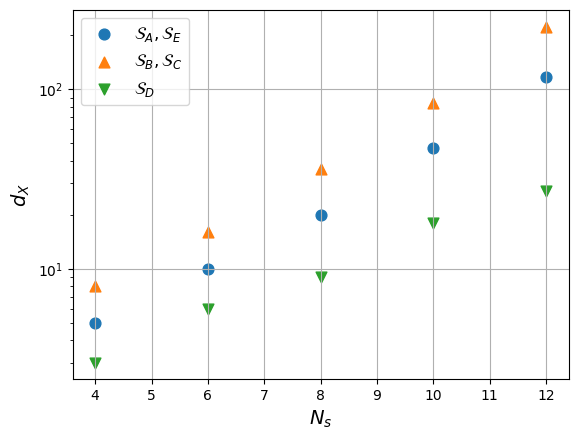

In [7]:
series = [
    ('g_m_h', r'$\mathcal{S}_A, \mathcal{S}_E$', 'o'),
    ('g_m_hsp', r'$\mathcal{S}_B, \mathcal{S}_C$', '^'),
    ('m_h', r'$\mathcal{S}_D$', 'v')
]
for config, symm, marker in series:
    plt.scatter(2 * num_fs, subspace_dims[config], 60., marker=marker, label=symm)

plt.grid()
plt.xlabel('$N_s$', fontsize=14)
plt.ylabel('$d_X$', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=12)
plt.savefig('/home/iiyama/src/z2vqe/plots/symsect_dim.pdf')

## Verifying irreducibility

In [8]:
sbds = {}
reducibles = []

for config in configs:
    sbds[config] = {}
    for inf, num_f in enumerate(num_fs[:-1]):
        with h5py.File(datadir / f'sbd-{config}-{num_f}.h5', 'r', libver='latest') as source:
            tr = source['transform'][()]
            blocks = [source[f'block{i}'][()] for i in range(len(source.keys()) - 1)]
            sbds[config][num_f] = (tr, blocks)
            if len(blocks) > 1:
                reducibles.append((config, num_f))

In [9]:
reducibles

[('g_h', np.int64(3)), ('g_h', np.int64(5))]

## DLA dimensions

In [10]:
dlas = {}

for config in configs:
    dlas[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'dla-{config}-{num_f}.h5', 'r', libver='latest') as source:
            dlas[config][int(num_f)] = source['dla_dim'][()]

In [11]:
dlas

{'g_m_h': {2: np.int64(25),
  3: np.int64(100),
  4: np.int64(400),
  5: np.int64(2209),
  6: np.int64(13924)},
 'g_m_hsp': {2: np.int64(63),
  3: np.int64(255),
  4: np.int64(1296),
  5: np.int64(7056),
  6: np.int64(50176)},
 'gsp_m_h': {2: np.int64(63),
  3: np.int64(255),
  4: np.int64(1296),
  5: np.int64(7056),
  6: np.int64(50176)},
 'm_h': {2: np.int64(3),
  3: np.int64(6),
  4: np.int64(6),
  5: np.int64(9),
  6: np.int64(9)},
 'g_h': {2: np.int64(10),
  3: np.int64(36),
  4: np.int64(190),
  5: np.int64(2208),
  6: np.int64(13924)}}

In [12]:
for config, nf in [('g_m_hsp', 4), ('g_m_hsp', 5), ('g_m_hsp', 6), ('gsp_m_h', 4), ('gsp_m_h', 5), ('gsp_m_h', 6), ('g_h', 4), ('g_h', 6)]:
    print(config, nf)
    print(generators[config][nf].shape[1] ** 2, dlas[config][nf])
    print(clean_array(np.trace(generators[config][nf], axis1=1, axis2=2)))

g_m_hsp 4
1296 1296
[0. 0. 0. 0.]
g_m_hsp 5
7056 7056
[0. 0. 0. 0.]
g_m_hsp 6
50176 50176
[0. 0. 0. 0.]
gsp_m_h 4
1296 1296
[0. 0. 0. 0.]
gsp_m_h 5
7056 7056
[0. 0. 0. 0.]
gsp_m_h 6
50176 50176
[0. 0. 0. 0.]
g_h 4
400 190
[0. 0.]
g_h 6
13924 13924
[0. 0.]


In [13]:
for config, nf in reducibles:
    print(config, nf)
    print(sbds[config][nf][1][1].shape[1] ** 2, dlas[config][nf])
    print(clean_array(np.trace(sbds[config][nf][1][1], axis1=1, axis2=2)))

g_h 3
81 36
[0. 0.]
g_h 5
2116 2208
[0. 0.]


In [14]:
# Correct by hand
dlas['g_m_hsp'][4] -= 1
dlas['g_m_hsp'][5] -= 1
dlas['g_m_hsp'][6] -= 1
dlas['gsp_m_h'][4] -= 1
dlas['gsp_m_h'][5] -= 1
dlas['gsp_m_h'][6] -= 1
dlas['g_h'][4] = 190
for nf in [4, 5, 6]:
    dlas['g_h'][nf] = subspaces['g_h'][nf].shape[1] * (subspaces['g_h'][nf].shape[1] - 1) // 2

In [15]:
dla_dims = {conf: np.array([dlas[conf][nf] for nf in num_fs]) for conf in configs}

INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


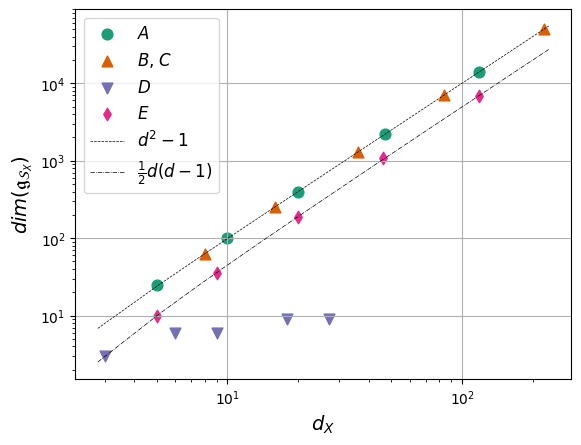

In [16]:
series = [
    ('g_m_h', '$A$', 'o'),
    ('gsp_m_h', '$B$, $C$', '^'),
    ('m_h', '$D$', 'v'),
    ('g_h', '$E$', 'd')
]
colors = mpl.color_sequences['Dark2']

for (config, label, marker), color in zip(series, colors):
    plt.scatter(subspace_dims[config], dla_dims[config], 40. if marker == 'd' else 60., color=color, marker=marker, label=label)
xfine = np.linspace(min(s[0] for s in subspace_dims.values()) - 0.2, max(s[-1] for s in subspace_dims.values()) + 10, 100)
plt.plot(xfine, xfine ** 2 - 1, color='k', linestyle='--', linewidth=0.5, label='$d^2 - 1$')
plt.plot(xfine, xfine * (xfine - 1) / 2, color='k', linestyle='-.', linewidth=0.5, label=r'$\frac{1}{2}d(d-1)$')

plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=12);
plt.xlabel('$d_X$', fontsize=14)
plt.ylabel(r'$dim (\mathfrak{g}_{\mathcal{S}_X})$', fontsize=14)
plt.grid()

plt.savefig('/home/iiyama/src/z2vqe/plots/dim_dla.pdf')

In [17]:
dla_dims['g_h']

array([  10,   36,  190, 1081, 6903])

## QFIM saturation

In [18]:
rsats = {}
lcriticals = {}

for config in configs:
    rsats[config] = {}
    lcriticals[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'qfim-{config}-{num_f}.h5', 'r', libver='latest') as source:
            ranks = source['ranks'][()]
            num_layers = source['num_layers'][()]
            rsat, lcritical = get_rsat_lcritical(ranks, num_layers)
            rsats[config][int(num_f)] = rsat
            lcriticals[config][int(num_f)] = lcritical

In [19]:
rsats

{'g_m_h': {2: np.float64(8.0),
  3: np.float64(18.0),
  4: np.float64(38.0),
  5: np.float64(92.0),
  6: np.float64(234.0)},
 'g_m_hsp': {2: np.float64(14.0),
  3: np.float64(30.0),
  4: np.float64(70.0),
  5: np.float64(166.0),
  6: np.float64(446.0)},
 'gsp_m_h': {2: np.float64(14.0),
  3: np.float64(30.0),
  4: np.float64(70.0),
  5: np.float64(166.0),
  6: np.float64(446.0)},
 'm_h': {2: np.float64(2.0),
  3: np.float64(4.0),
  4: np.float64(4.0),
  5: np.float64(7.0),
  6: np.float64(7.0)},
 'g_h': {2: np.float64(4.0),
  3: np.float64(8.0),
  4: np.float64(19.0),
  5: np.float64(45.0),
  6: np.float64(117.0)}}

In [20]:
lcriticals

{'g_m_h': {2: np.int64(4),
  3: np.int64(8),
  4: np.int64(16),
  5: np.int64(32),
  6: np.int64(80)},
 'g_m_hsp': {2: np.int64(4),
  3: np.int64(8),
  4: np.int64(18),
  5: np.int64(48),
  6: np.int64(112)},
 'gsp_m_h': {2: np.int64(4),
  3: np.int64(8),
  4: np.int64(20),
  5: np.int64(48),
  6: np.int64(113)},
 'm_h': {2: np.int64(2),
  3: np.int64(4),
  4: np.int64(4),
  5: np.int64(52),
  6: np.int64(34)},
 'g_h': {2: np.int64(2),
  3: np.int64(8),
  4: np.int64(16),
  5: np.int64(24),
  6: np.int64(64)}}

In [21]:
rsat_nums = {conf: np.array([rsats[conf][nf] for nf in num_fs]) for conf in configs}

INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol g from STIXGeneral
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


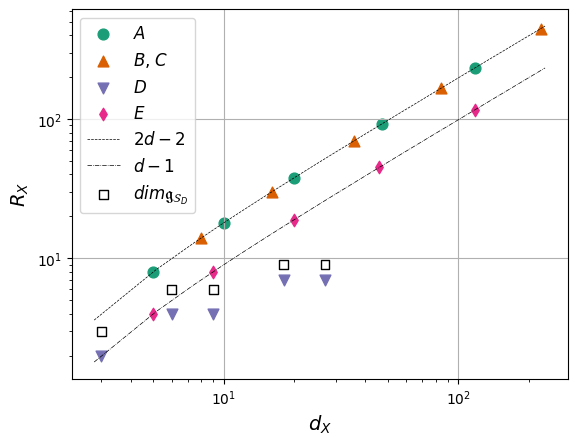

In [22]:
series = [
    ('g_m_h', '$A$', 'o'),
    ('gsp_m_h', '$B$, $C$', '^'),
    ('m_h', '$D$', 'v'),
    ('g_h', '$E$', 'd')
]
colors = mpl.color_sequences['Dark2']

for (config, label, marker), color in zip(series, colors):
    plt.scatter(subspace_dims[config], rsat_nums[config], 40. if marker == 'd' else 60., color=color, marker=marker, label=label)
xfine = np.linspace(min(s[0] for s in subspace_dims.values()) - 0.2, max(s[-1] for s in subspace_dims.values()) + 10, 100)
plt.plot(xfine, xfine * 2 - 2, color='k', linestyle='--', linewidth=0.5, label='$2d - 2$')
plt.plot(xfine, xfine - 1, color='k', linestyle='-.', linewidth=0.5, label='$d - 1$')
plt.scatter(subspace_dims['m_h'], dla_dims['m_h'], 40., color='k', marker='s', facecolor='none', label=r'$dim \mathfrak{g}_{\mathcal{S}_D}$')

plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=12);
plt.xlabel('$d_X$', fontsize=14)
plt.ylabel('$R_X$', fontsize=14)
plt.grid()

plt.savefig('/home/iiyama/src/z2vqe/plots/qfim_rsat.pdf')

### Critical number of layers and VQE convergence

In [44]:
num_layers = {}
losses = {}
loglosses = {}
stepsizes = {}

#for config in configs:
for config in ['g_m_h']:
    num_layers[config] = {}
    losses[config] = {}
    loglosses[config] = {}
    stepsizes[config] = {}
    # for num_f in num_fs:
    for num_f in [4]:
        with h5py.File(datadir / f'vqe-{config}-{num_f}-iter100.h5', 'r', libver='latest') as source:
            num_layers[config][num_f] = source['num_layers'][()]
            energies = source['energies'][()]
            losses[config][num_f] = energies.copy()
            exact = source['exact_e0'][()]
            energies -= exact
            loglosses[config][num_f] = np.log(np.where(np.isclose(energies, 0.), 1.e-12, energies))
            stepsizes[config][num_f] = source['therm_stepsizes'][()]
            stepsize = source['run_stepsize'][()]

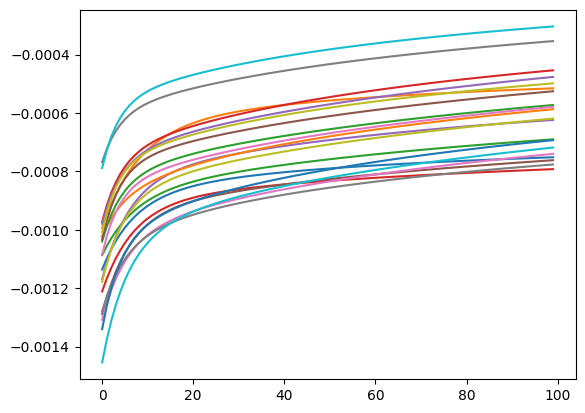

In [43]:
meanloss = np.mean(losses['g_m_h'][4], axis=1)
plt.plot(np.diff(meanloss, axis=-1)[:, 20:].T)

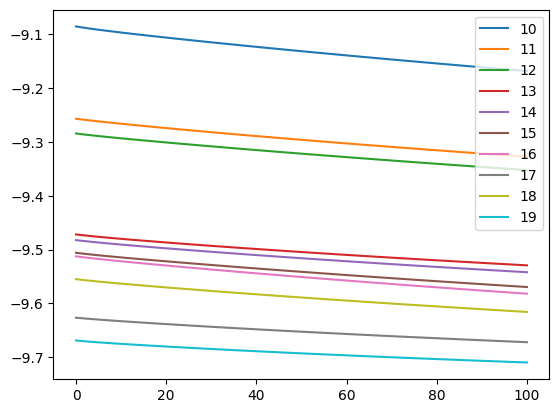

In [96]:
plt.plot(meanloss[10:, 20:].T, label=[f'{i}' for i in range(10, 20)])
plt.legend();

In [64]:
meanloss.shape

(20, 121)

In [70]:
dloss = np.diff(meanloss, axis=1)
rdloss = dloss[:, 1:] / dloss[:, :-1]

In [71]:
rdloss.shape

(20, 119)

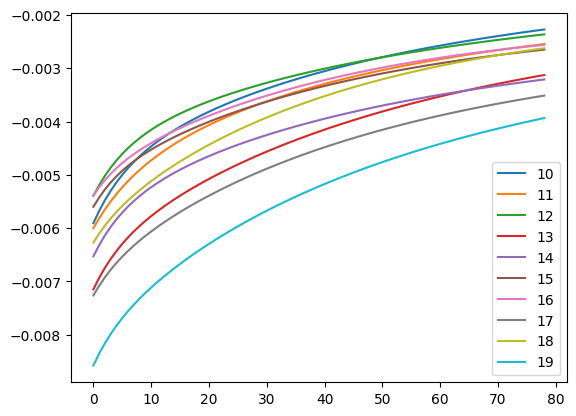

In [75]:
plt.plot(np.log(rdloss[10:, 40:]).T, label=[f'{i}' for i in range(10, 20)])
plt.legend();

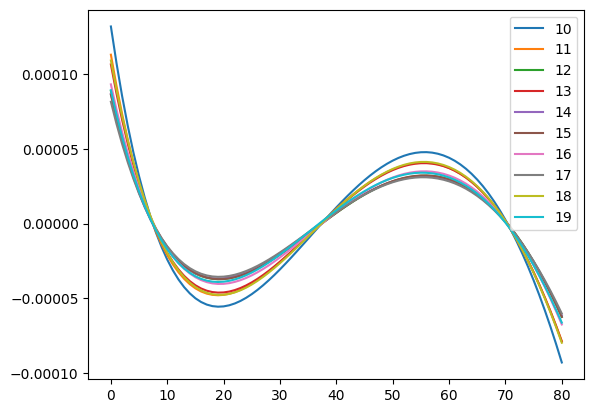

In [92]:
from scipy.optimize import curve_fit

def curve(x, a, b, c):
    return a + np.exp(-b * x + c)

popts = []
for inl in range(10, 20):
    popt, pcov = curve_fit(curve, np.arange(20, 101), meanloss[inl, 40:], p0=(exact, 0., -1.))
    plt.plot(meanloss[inl, 40:] - curve(np.arange(20, 101), *popt), label=f'{inl}')
    popts.append(popt)

plt.legend();

In [90]:
popt

array([-9.37988030e+00,  3.20763141e-03, -1.23044114e+00])

In [50]:
meanloss.shape

(20, 121)

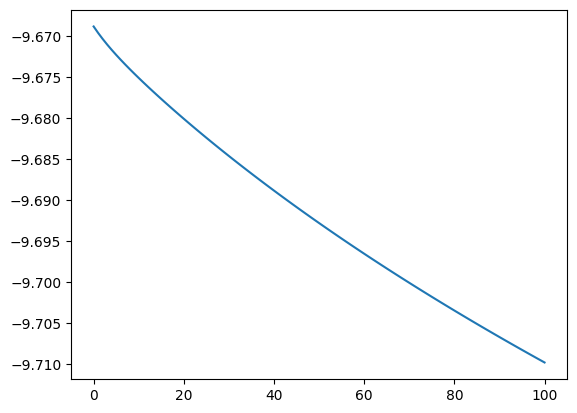

In [55]:
plt.plot(meanloss[-1, 20:])

In [29]:
nf = 4
stepsizes['g_m_h'][nf].shape

(20, 64, 20)

In [30]:
ntherm = stepsizes['g_m_h'][nf].shape[-1]
dll = {nf: np.mean(np.diff(loglosses['g_m_h'][nf][:, :, ntherm:], axis=2) / stepsize, axis=1) for nf in [4]} # / num_layers['g_m_h'][nf][:, None]

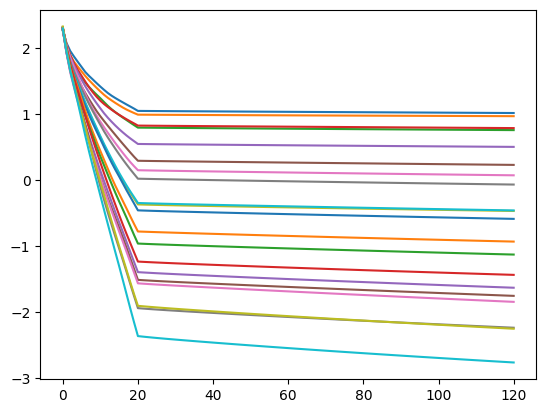

In [27]:
plt.plot(np.mean(loglosses['g_m_h'][4], axis=1).T)

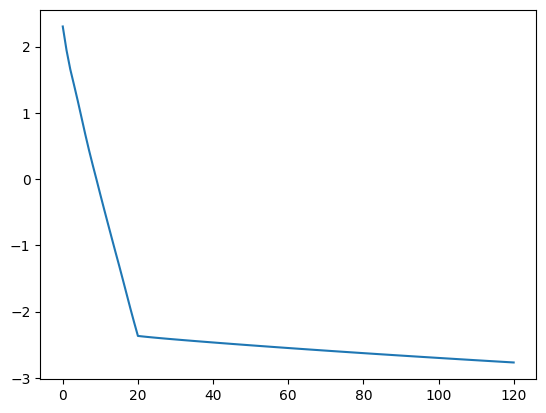

In [32]:
llmean = np.mean(loglosses['g_m_h'][4], axis=1)
plt.plot(llmean[-1])

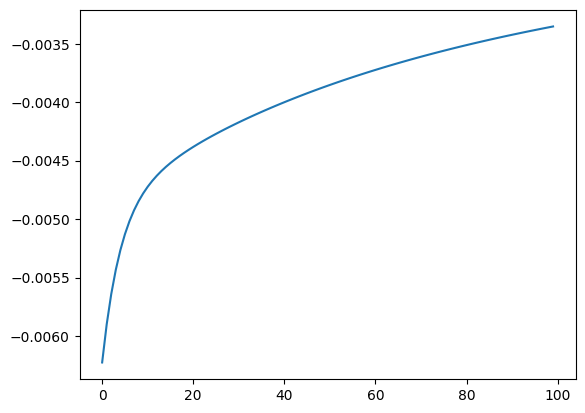

In [34]:
plt.plot(np.diff(llmean[-1])[20:])

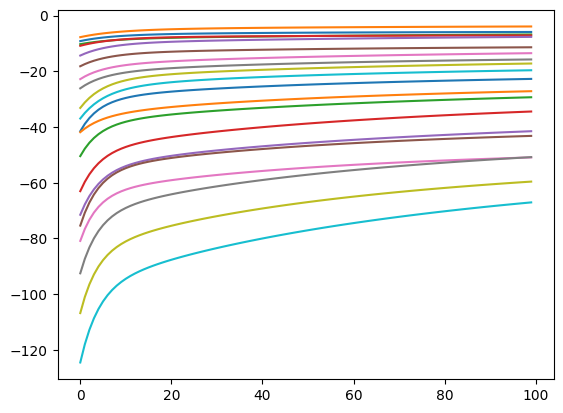

In [31]:
plt.plot(dll[4].T)

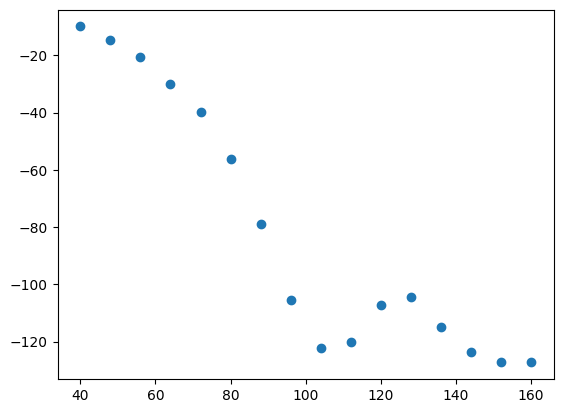

In [55]:
plt.scatter(num_layers['g_m_h'][6], np.mean(dll[6][:, 60:], axis=1))

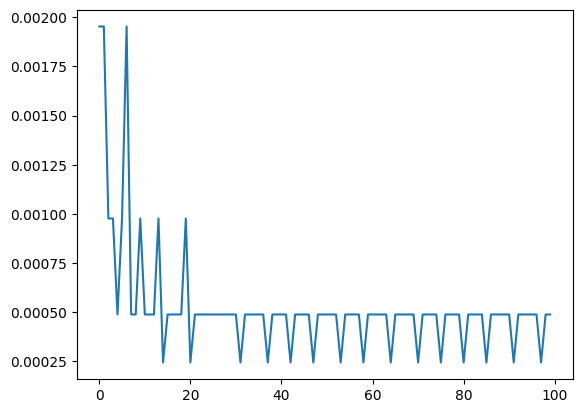

In [58]:
plt.plot(stepsizes['g_m_h'][6][-1, 0])

In [93]:
losses['g_m_h'][4].shape

(20, 128, 1001)

In [ ]:
losses['g_m_h'][4][:, ]

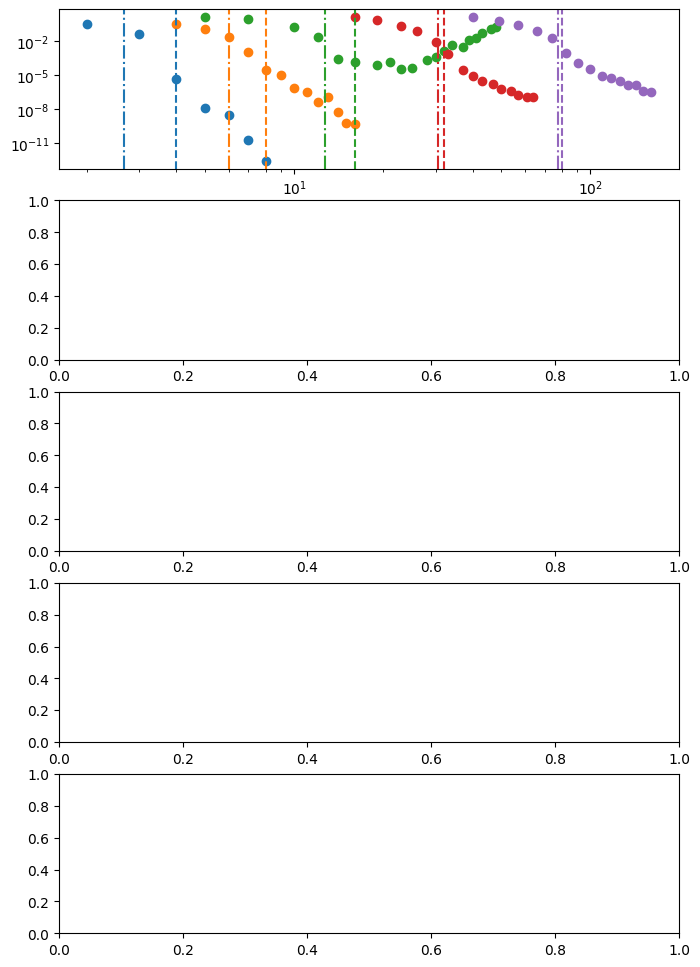

In [98]:
fig, axs = plt.subplots(5, 1, figsize=(8, 12))

for config, num_terms, ax in zip(configs[:1], [3], axs):
    for num_f in num_fs:
        lc = lcriticals[config][num_f]
        mean = np.mean(losses[config][num_f][:, :, -1], axis=1)
        paths = ax.scatter(num_layers[config][num_f], mean, label=f'$N_s={2 * num_f}$')
        ax.axvline(lc, color=paths.get_facecolor(), linestyle='--')
        ax.axvline(rsats[config][num_f] / num_terms, color=paths.get_facecolor(), linestyle='-.')
        ax.set_xscale('log')
        ax.set_yscale('log')

In [81]:
paths.get_facecolor()

array([[0.58039216, 0.40392157, 0.74117647, 1.        ]])

In [ ]:
subspace_dims = {}
dlas = {}
qfim_ranks = {}
subspace_dims = np.zeros((len(configs), len(num_fs)), dtype=int)
dlas = np.zeros((len(configs), len(num_fs)), dtype=int)
qfim_ranks = np.zeros((len(configs), len(num_fs)), dtype=int)
for iconfig, config in enumerate(configs):
    for inum, num_f in enumerate(num_fs):
        path = pathtemp.format(config=config, num_fermions=num_f)
        if not os.path.exists(path):
            continue
        with h5py.File(path, 'r', libver='latest') as source:
            print(config, num_f, source['blocks'][()])
            subspace_dims[iconfig, inum] = source['subspace'].shape[1]
            dlas[iconfig, inum] = source['dla'].shape[0]
            qfim_ranks[iconfig, inum] = source['qfim_ranks'][-1]

g_m_h 2 [5]
g_m_h 3 [10]
g_m_h 4 [20]
g_m_h 5 [47]
g_m_h 6 [118]
g_m_hsp 2 [8]
g_m_hsp 3 [16]
g_m_hsp 4 [36]
g_m_hsp 5 [84]
gsp_m_h 2 [8]
gsp_m_h 3 [16]
gsp_m_h 4 [36]
gsp_m_h 5 [84]
g_h 2 [5]
g_h 3 [1 9]
g_h 4 [20]
g_h 5 [ 1 46]
g_h 6 [118]
m_h 2 [2 3]
m_h 3 [1 3 6]
m_h 6 [118]


(np.int64(3), np.int64(128))

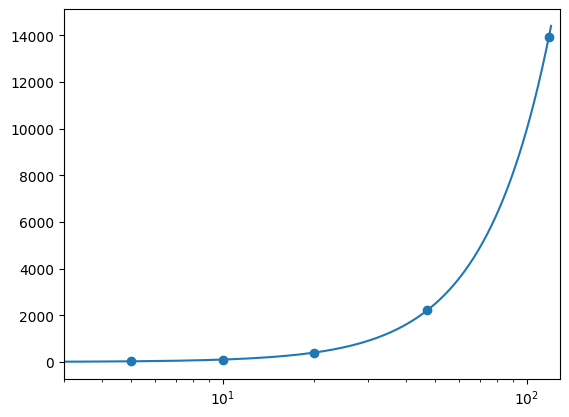

In [ ]:
xfine = np.linspace(1., 120., 200)
plt.scatter(subspace_dims[0], dlas[0])
plt.plot(xfine, xfine * xfine - 1.)
plt.xscale('log')
plt.xlim(np.min(subspace_dims[:, 0]) - 2, np.max(subspace_dims[:, -1]) + 10)

In [25]:
a = np.random.random((5, 5)) + 1.j * np.random.random((5, 5))
a += a.conjugate().T
a *= 1.j
b = np.random.random((5, 5)) + 1.j * np.random.random((5, 5))
b += b.conjugate().T
b *= 1.j

In [26]:
np.trace(a.conjugate().T @ b)

np.complex128(33.433754460414775+4.718447854656915e-16j)

In [28]:
atri = np.concatenate([a[i, i+1:] for i in range(5)])
btri = np.concatenate([b[i, i+1:] for i in range(5)])
c = atri.conjugate() @ btri
print(c + c.conjugate() + np.diagonal(a.conjugate()) @ np.diagonal(b))
print(c.real * 2. + np.diagonal(a.conjugate()) @ np.diagonal(b))

(33.43375446041477+0j)
(33.43375446041477+0j)


## DLA dims

In [13]:
dlas = {}
for config in configs[]:
    dlas[config] = {}
    for num_f in num_fs:
        with h5py.File(datadir / f'dla-{config}-{num_f}.h5', 'r', libver='latest') as source:
            dlas[config][int(num_f)] = source['dla'][()]

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/data/iiyama/z2vqe/dla-g_m_h-7.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [16]:
[dlas['g_m_h'][nf].shape for nf in num_fs]

[(25, 5, 5), (100, 10, 10), (400, 20, 20), (1971, 47, 47), (10768, 118, 118)]

In [12]:
x = np.arange(35, 47)
x ** 2 + (47 - x) ** 2

array([1369, 1417, 1469, 1525, 1585, 1649, 1717, 1789, 1865, 1945, 2029,
       2117])

In [16]:
44 ** 2

1936

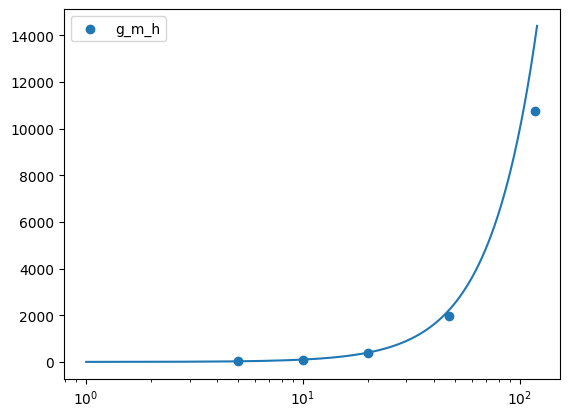

In [ ]:
for config in ['g_m_h']:
    subspace_dims = np.array([subspaces[config][nf].shape[1] for nf in num_fs])
    dlas = np.array([dlas[config][nf].shape[0] for nf in num_fs])
    plt.scatter(subspace_dims, dlas, label=config)

xfine = np.linspace(1., 120., 200)
plt.plot(xfine, xfine * xfine - 1.)
plt.xscale('log')
plt.legend();